<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/4.2-feature-extraction-rav_and_crema.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Feature Extraction & Data Routing: Arquitectura Robusta

En este notebook se realiza el proceso de **extracción de características** y generación de imágenes a partir de dos bases de datos: **RAVDESS** (proceso detallado en el notebook anterior) y **CREMA-D** (*Crowd-sourced Emotional Multimodal Actors Dataset*), mediante la implementación un pipeline de **Data Handling** metodológicamente riguroso para Speech Emotion Recognition (SER).

CREMA-D es un conjunto de datos que consta de **7,442 clips originales** interpretados por 91 actores (48 hombres y 43 mujeres) de entre 20 y 74 años, pertenecientes a diversas etnias. Los actores grabaron una selección de 12 oraciones bajo 6 categorías emocionales distintas. Puedes consultar los detalles técnicos aquí: [CREMA-D en Kaggle](https://www.kaggle.com/datasets/ejlok1/cremad).

Como se observará más adelante, debido a que CREMA-D no incluye las emociones *calm* (calma) ni *surprised* (sorpresa), se han tomado **decisiones fundamentales** para el tratamiento de estas clases durante el proceso de extracción:

1. **Fusión de Clases:** Se decidió fusionar la clase *calm* de RAVDESS con la clase *neutral*. Esto se debe a que, en pruebas previas de clasificación (Machine Learning, Deep Learning y pruebas auditivas con personas), la diferencia acústica y perceptual entre ambas es mínima.

2. **Data Augmentation (Surprised):** Dado que la clase *surprised* solo está presente en RAVDESS, se aplica un proceso exclusivo de **aumento de datos** mediante la inclusión de ruido (*AWGN*) y desplazamiento temporal (*time shift*). Los detalles técnicos se encuentran documentados en las líneas de código correspondientes.

_Nota de la ultima versión:_

### Análisis de Suposiciones Previas y Correcciones

1. **Falla de Suposición (Speaker Leakage):** Asumir que la partición aleatoria de archivos (`random_split`) es válida.
   * **Corrección:** La partición debe ser **Speaker-Independent**. Si el mismo actor existe en Train y Test, la Red Neuronal Convolucional (CNN) memorizará el tracto vocal del locutor en lugar de los patrones espectrales de la emoción. Este notebook extrae el ID de cada actor y realiza la partición a nivel de individuo antes de procesar el audio.

2. **Falla de Suposición (Data Leakage por Augmentation):** Asumir que el ruido blanco y el desplazamiento temporal pueden aplicarse a todo el dataset para balancear clases.
   * **Corrección:** Los conjuntos de Validación y Test **nunca** deben contener datos sintéticos. Evaluar un modelo sobre un audio artificialmente modificado destruye la validez de la métrica. El aumento de datos (clase `surprised`) se restringe estrictamente a los actores asignados al conjunto de Entrenamiento.

3. **Falla de Suposición (Global Standard Scaling):** Aplicar `StandardScaler` a todo el CSV antes de particionar.
   * **Corrección:** Escalar usando la media y varianza global contamina el modelo, ya que le otorga información estadística del conjunto de prueba durante el entrenamiento. El CSV generado aquí contendrá los datos numéricos puros (raw). El escalado y la interpolación (SMOTE) deben aplicarse en el [notebook de entrenamiento](https://github.com/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/5.2-model-training-with-agumentation.ipynb), exclusivamente sobre el *Train split*.

In [1]:
# Importar librerias necesarias
#------------------------------------------------------------
import IPython.display as ipd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import gc, random
import kagglehub
import matplotlib
import os
import logging
import sklearn.preprocessing
#-------------------------------------------------------------
from pandas import DataFrame
from google.colab import drive
from sklearn.preprocessing import StandardScaler
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
#-------------------------------------------------------------
matplotlib.use('Agg')  # Backend sin GUI para eficiencia de memoria
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s', stream=sys.stdout, force=True)

In [2]:
# Download latest version desde Kaggle
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
path_crema = kagglehub.dataset_download("ejlok1/cremad")

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
Using Colab cache for faster access to the 'cremad' dataset.


In [42]:
# Variables de configuración y rutas
#--------------------------------------------------------------------------
FAST_ROOT_DIR = '/content/features_local/ravdess-and-crema-images'
os.makedirs(FAST_ROOT_DIR, exist_ok=True)


# Config
SAMPLE_RATE = 22050
MIN_DURATION = 0.5
MAX_DURATION = 3
TARGET_SAMPLES = (SAMPLE_RATE * MAX_DURATION )
FEATURES_TO_EXTRACT = ['mfcc', 'mel_spec']
IMG_RES = (224, 224)
PAD_MODE = "constant" # Para padding de audios cortos

# Rutas Faster
#-------------------------------------------------------------------------

OUT_DIR_IMAGES = '/content/dataset_split_images'
OUT_DIR_CSV = '/content/features_csv_raw.csv'


In [4]:
# Copiamos a local(session) para mayor velociadad en el procesamiento

!cp -r {path}/* {FAST_ROOT_DIR}
!cp -r {path_crema}/* {FAST_ROOT_DIR}


In [40]:
list = os.listdir(FAST_ROOT_DIR)
if len(list) > 0:
  print("FAST_ROOT_DIR contiene archivos")
  print("-------------------------------")
  print("Puede continuar con el procesamiento")

else:
  print(f"FAST_ROOT_DIR está vacío{list}")
  print("-------------------------------")
  print("revise path y path_crema")


FAST_ROOT_DIR contiene archivos
-------------------------------
Puede continuar con el procesamiento


In [53]:
# En caso de revision de codigo y evitar procesamiento pesado:

# FLAGS
GENERATE_CSV = True # Poner en False para desacativar la generacion de archivo CSV
GENERATE_IMAGES = False # Poner en False para desacativar la generacion de Imagenes

### Speaker-Independent Splitting Logic
Antes de tocar un solo tensor de audio, analizamos la nomenclatura de los archivos para extraer la identidad del locutor y la emoción. Luego, particionamos a los actores matemáticamente.

In [24]:
def get_actor_and_emotion(filename):
  """Extrae Actor ID y Emoción basándose en la nomenclatura estricta de RAVDESS/CREMA-D"""
  if filename.startswith('03'): # Nomenclatura Ravdess (ej. 03-02-XX-01-01-02.wav)
    parts = filename.split('-')
    if len(parts) != 7: return 'unknown'
    actor_id = f"ravdess_{parts[-1].replace('.wav', '')}" # En Python, los índices negativos cuentan desde el final hacia atrás
    rav_map = {1:'neutral', 2:'neutral', 3:'happy', 4:'sad', 5:'angry', 6:'fearful', 7:'disgust', 8:'surprised'}
    emotion = rav_map.get(int(parts[2]), 'unknown')
    return actor_id, emotion

  else: # Nomenclatura CREMA-D (ej. 1001_DFA_ANG_XX.wav)
      parts = filename.split('_')
      if len(parts) < 3: return None, 'unknown'
      actor_id = f"crema_{parts[0]}"
      crema_map = {'NEU':'neutral', 'HAP':'happy', 'SAD':'sad', 'ANG':'angry', 'FEA':'fearful', 'DIS':'disgust'}
      emotion = crema_map.get(parts[2].upper(), 'unknown')
      return actor_id, emotion


# 1. Mapeo de archivos físicos
all_files = [os.path.join(root, f) for root, dirs, files in os.walk(FAST_ROOT_DIR) for f in files if f.endswith('.wav')]
actor_to_files = {}

for f in all_files:
    actor, emo = get_actor_and_emotion(os.path.basename(f))
    if emo == 'unknown': continue
    if actor not in actor_to_files: actor_to_files[actor] = []
    actor_to_files[actor].append(f)

# 2. Partición estocástica de Actores (80% Train, 10% Val, 10% Test)
unique_actors = list(actor_to_files.keys())
random.seed(42) # Semilla inmutable para consistencia entre ejecuciones
random.shuffle(unique_actors)

train_split = int(0.8 * len(unique_actors))
val_split = int(0.9 * len(unique_actors))

actor_splits = {}
for a in unique_actors[:train_split]: actor_splits[a] = 'train'
for a in unique_actors[train_split:val_split]: actor_splits[a] = 'val'
for a in unique_actors[val_split:]: actor_splits[a] = 'test'

print(f"Total Actores: {len(unique_actors)} | Train: {train_split} | Val: {val_split - train_split} | Test: {len(unique_actors) - val_split}")


Total Actores: 115 | Train: 92 | Val: 11 | Test: 12


## Extracción Tabular Pura (CSV)

**1.La Invarianza Matemática del Desplazamiento Temporal (Time Shift)**

En el pipeline de imágenes, el espectrograma conserva la dimensión temporal en el eje X. Un desplazamiento de la onda (shift) traslada los píxeles hacia la izquierda o derecha, forzando a la red convolucional (CNN) a ser invariante a la traslación.

* En el pipeline del CSV, colapsamos la dimensión temporal calculando la media y la desviación estándar: np.mean(mfccs, axis=1). Matemáticamente, la media de un conjunto de valores es invariante al orden de esos valores. Si aplicas un desplazamiento temporal (np.roll) a la señal de audio, los valores de los MFCCs cambian de posición en el tiempo, pero su media y desviación estándar global serán virtualmente idénticas a las del audio original (salvo por artefactos minúsculos en los bordes).

* Si hubiéramos incluido el shift en el CSV, habríamos insertado filas duplicadas. Como discutimos antes, filas idénticas en el set de entrenamiento causan sobreajuste (overfitting) en los árboles de decisión, porque el modelo memoriza ese vector exacto.

**2.El Espacio de Características vs. El Espacio de la Señal (Noise)**


Aplicar ruido blanco (noise_adder) sí altera la media y la desviación estándar de los MFCCs, generando un vector numérico distinto. Sin embargo, en el paradigma de Machine Learning tabular (Model Lifecycle), alterar la señal cruda para generar nuevas filas estáticas es una técnica obsoleta e ineficiente por dos razones:

* Control de la Distribución: Al inyectar ruido acústico, no tienes control sobre cómo se desplaza el vector en el espacio hiperdimensional de 125 características. Podrías generar vectores que se solapen con la clase fearful o angry, degradando los límites de decisión (decision boundaries) de tu clasificador.


* El Estándar de la Industria (SMOTE): Para datos tabulares, el balanceo de clases se realiza en el espacio de características (Feature Space), no en el espacio de la señal. Técnicas como SMOTE (Synthetic Minority Over-sampling Technique) toman los vectores de la clase minoritaria (surprised) e interpolan matemáticamente nuevos puntos que pertenecen estrictamente a esa clase. Esto genera límites de decisión mucho más limpios para un Random Forest o un MLP.

**3.Separación de Preocupaciones (Data Handling)**

Al no incluir el aumento de datos en el CSV de origen, hemos creado lo que en ingeniería de datos se conoce como un Gold Standard Dataset.

* Es un dataset inmutable y puro. **Contiene exclusivamente la verdad fundamental de las grabaciones.**

* Si hubiéramos inyectado ruido en la creación del CSV para los audios de Train, habríamos acoplado permanentemente una decisión de hiperparámetros (la cantidad de ruido o balanceo) al archivo físico de datos. Si mañana decides que necesitas 3 veces más datos de surprised, o que el ruido era muy alto, tendrías que volver a procesar miles de archivos de audio desde cero.

In [44]:
# Extraccion de features dedicada a CSV

def extract_tabular_features(y, sr):
    try:
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=14)[1:,:]
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048)
        mel_spec_db = librosa.power_to_db(mel_spec)
        rmse = librosa.feature.rms(y=y)
        delta = librosa.feature.delta(mfccs)
        delta2 = librosa.feature.delta(mfccs, order=2)

        return np.concatenate([
            np.mean(mfccs, axis=1), np.std(mfccs, axis=1),
            np.mean(delta, axis=1), np.std(delta, axis=1),
            np.mean(delta2, axis=1), np.std(delta2, axis=1),
            [np.mean(rmse), np.std(rmse), np.mean(mel_spec_db), np.std(mel_spec_db)]
        ])
    except Exception:
        return None

if GENERATE_CSV:

  def process_single_file_for_csv(file_path):
      filename = os.path.basename(file_path)
      actor_id, emotion = get_actor_and_emotion(filename)
      split_name = actor_splits.get(actor_id, 'unknown')

      if split_name == 'unknown': return None

      try:
          y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
          y_trimmed, _ = librosa.effects.trim(y, top_db=45)
          y_norm = librosa.util.normalize(y_trimmed)
          if (len(y_norm) / sr) < MIN_DURATION: return None

          y_fixed = librosa.util.fix_length(y_norm, size=TARGET_SAMPLES)
          feats = extract_tabular_features(y_fixed, sr)

          if feats is not None:
              return {'features': feats, 'emotion': emotion, 'actor_id': actor_id, 'split': split_name, 'filename': filename}
      except:
          pass
      return None

  print("Iniciando extracción tabular paralela...")
  all_csv_data = []
  with ProcessPoolExecutor() as executor:
      futures = {executor.submit(process_single_file_for_csv, fp): fp for fp in all_files}
      for future in tqdm(as_completed(futures), total=len(all_files)):
          res = future.result()
          if res: all_csv_data.append(res)

  if all_csv_data:
      columns = ([f'mfcc_mean_{i}' for i in range(13)] + [f'mfcc_std_{i}' for i in range(13)] +
                [f'delta_mean_{i}' for i in range(13)] + [f'delta_std_{i}' for i in range(13)] +
                [f'delta2_mean_{i}' for i in range(13)] + [f'delta2_std_{i}' for i in range(13)] +
                ['rmse_mean', 'rmse_std', 'mel_mean', 'mel_std'])

      df = pd.DataFrame([x['features'] for x in all_csv_data], columns=columns)
      df['emotion'] = [x['emotion'] for x in all_csv_data]
      df['actor_id'] = [x['actor_id'] for x in all_csv_data]
      df['split'] = [x['split'] for x in all_csv_data]
      df['filename'] = [x['filename'] for x in all_csv_data]

      df = df.drop_duplicates(subset=['filename']) # Deduplicación crítica por la estructura de Kaggle
      df.to_csv(OUT_DIR_CSV, index=False)
      print(f"CSV puro guardado en {OUT_DIR_CSV} con {len(df)} filas.")

else:
  print("La generacion de CSV está desactivada")

Iniciando extracción tabular paralela...


100%|██████████| 10322/10322 [08:18<00:00, 20.72it/s]


CSV puro guardado en /content/features_csv_raw.csv con 8882 filas.


Compiamos el archivo a nuestra carpeta en Drive para no perderlo al finalizar sesion, es nuestra copia de seguridad.

In [50]:
#from google.colab import drive
drive.mount('/content/drive')
drive_dir = '/content/drive/MyDrive/features_csv/features_csv_raw.csv'
# Guardando CSV a nuestro Drive (opcional)
#!cp  /content/features_csv_raw.csv /content/drive/MyDrive/features_csv


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
df =  pd.read_csv(drive_dir)

In [10]:
print("Contenido del dataframe:")
print("-------------------------")
print(f"{len(df.columns)} Columnas x {len(df)} Filas")

Contenido del dataframe:
-------------------------
128 Columnas x 8882 Filas


In [52]:
print("Cantidad de filas por emocion:")
df['emotion'].value_counts()

Cantidad de filas por emocion:


,count
emotion,
angry,1463
sad,1463
fearful,1463
disgust,1463
happy,1463
neutral,1375
surprised,192


### Extracción Espacial 2D (Imágenes) con Enrutamiento Físico Directo
Para arquitecturas 2D-CNN (ej. EfficientNet), estructuramos el disco para ser consumido nativamente por `ImageFolder` de PyTorch.
**Regla Crítica Aplicada:** El aumento de datos (ruido AWGN y time shift) se condiciona estrictamente mediante `if emotion == 'surprised' and split_name == 'train':`, blindando los conjuntos de validación contra contaminación sintética.

### Procesamiento de coeficientes cesptrales
1. **Omisión del primer coeficiente:** El coeficiente 0 (MFCC-0) representa el nivel de energía continua (DC offset) o el volumen general del marco de audio. Dado que los audios de RAVDESS y CREMA-D tienen diferentes niveles de ganancia y distancias al micrófono, el MFCC-0 actúa como una variable de confusión. Descartarlo fuerza al modelo a concentrarse en la forma del espectro y no en qué tan fuerte gritó el actor respecto al micrófono.

2. **Estadarizacion con Numpy:** En lugar de normalizar toda la matriz junta, aplicamos estandarización (media 0, varianza 1) a cada coeficiente independientemente a lo largo del eje del tiempo (axis=1). Esto fuerza a que las variaciones sutiles del MFCC-12 resalten visualmente tanto como las del MFCC-1. Aquí el uso de la variable **epsilon = 1e-8** es imprescindible, para evitar errores por división por cero.



In [57]:
# Funciones de alteración de señal
def noise_adder(y):
    return y + (0.040 * np.random.uniform() * np.amax(y)) * np.random.normal(size=y.shape[0])

def shift(y):
    return np.roll(y, int(np.random.uniform(low=-5, high=5) * 1000))

# Funcion para guardad las imagenes en 224x224
def save_images(data, sr, out_path, feature_type):
    # Forzamos dimensiones exactas sin ejes ni bordes blancos
    fig = plt.figure(figsize=(IMG_RES[0]/100, IMG_RES[1]/100), dpi=100)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.axis('off')

    if feature_type == 'mel_spec':
        librosa.display.specshow(librosa.power_to_db(data, ref=np.max), sr=sr, cmap='inferno', ax=ax)
    elif feature_type == 'mfcc':
        # TECHNICAL PRECISION: Estandarización nativa con Epsilon para evitar división por cero
        # data tiene forma (coeficientes, frames temporales). Operamos sobre el eje 1 (tiempo).
        mean = np.mean(data, axis=1, keepdims=True)
        std = np.std(data, axis=1, keepdims=True)
        epsilon = 1e-8

        data_scaled = (data - mean) / (std + epsilon)
        #Coolwarm ofrece un exelente contraste, matematicamente recomendado :)
        librosa.display.specshow(data_scaled, sr=sr, cmap='coolwarm', ax=ax)

    plt.savefig(out_path, transparent=True, bbox_inches='tight', pad_inches=0)
    fig.clear()
    plt.close(fig)

def process_single_file_for_images(file_path):
    filename = os.path.basename(file_path)
    actor_id, emotion = get_actor_and_emotion(filename)
    split_name = actor_splits.get(actor_id, 'unknown')

    if split_name == 'unknown': return False

    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
        y_trimmed, _ = librosa.effects.trim(y, top_db=45)
        y_fixed = librosa.util.fix_length(y_trimmed, size=TARGET_SAMPLES)

        audio_versions = {'original': y_fixed}

        # Prevención de fuga de datos: Augmentation SOLO en train para surprised
        if emotion == 'surprised' and split_name == 'train':
            audio_versions['noise'] = librosa.util.fix_length(noise_adder(y_trimmed), size=TARGET_SAMPLES)
            audio_versions['shift'] = librosa.util.fix_length(shift(y_trimmed), size=TARGET_SAMPLES)

        prefix = "r_" if filename.startswith('03-') else "c_"

        for feature in FEATURES_TO_EXTRACT:
            # Enrutamiento estricto para ImageFolder
            emotion_dir = os.path.join(OUT_DIR_IMAGES, feature, split_name, emotion)
            os.makedirs(emotion_dir, exist_ok=True)

            for version_name, y_version in audio_versions.items():
                out_name = f"{prefix}{filename.replace('.wav', '.png')}" if version_name == 'original' else f"{prefix}{version_name}_{filename.replace('.wav', '.png')}"
                out_path = os.path.join(emotion_dir, out_name)

                if os.path.exists(out_path):
                    continue

                if feature == 'mel_spec':
                    data = librosa.feature.melspectrogram(y=y_version, sr=sr, n_mels=128, fmax=8000, fmin=20)
                elif feature == 'mfcc':
                    # Extraemos 14 coeficientes y descartamos el MFCC-0 (índice 0)
                    data = librosa.feature.mfcc(y=y_version, sr=sr, n_mfcc=14)[1:, :]

                save_images(data, sr, out_path, feature)

        return True
    except Exception as e:
        print(f"Error procesando {filename}: {str(e)}")
        return False

### Validación Visual Preventiva

Creamos una visualización aleatoria de cuatro **imágenes** dentro del conjunto para tener una vista previa del resultado final antes de procesar el dataset completo. De esta manera, evitamos tener que **llevar a cabo** el procesamiento total —que toma **alrededor de 40 minutos**— solo para descubrir posibles errores en el formato de salida. En el peor de los casos, esta validación nos previene de tener que generar nuevamente el conjunto de **8,882 archivos PNG**.

Generando imágenes de prueba...


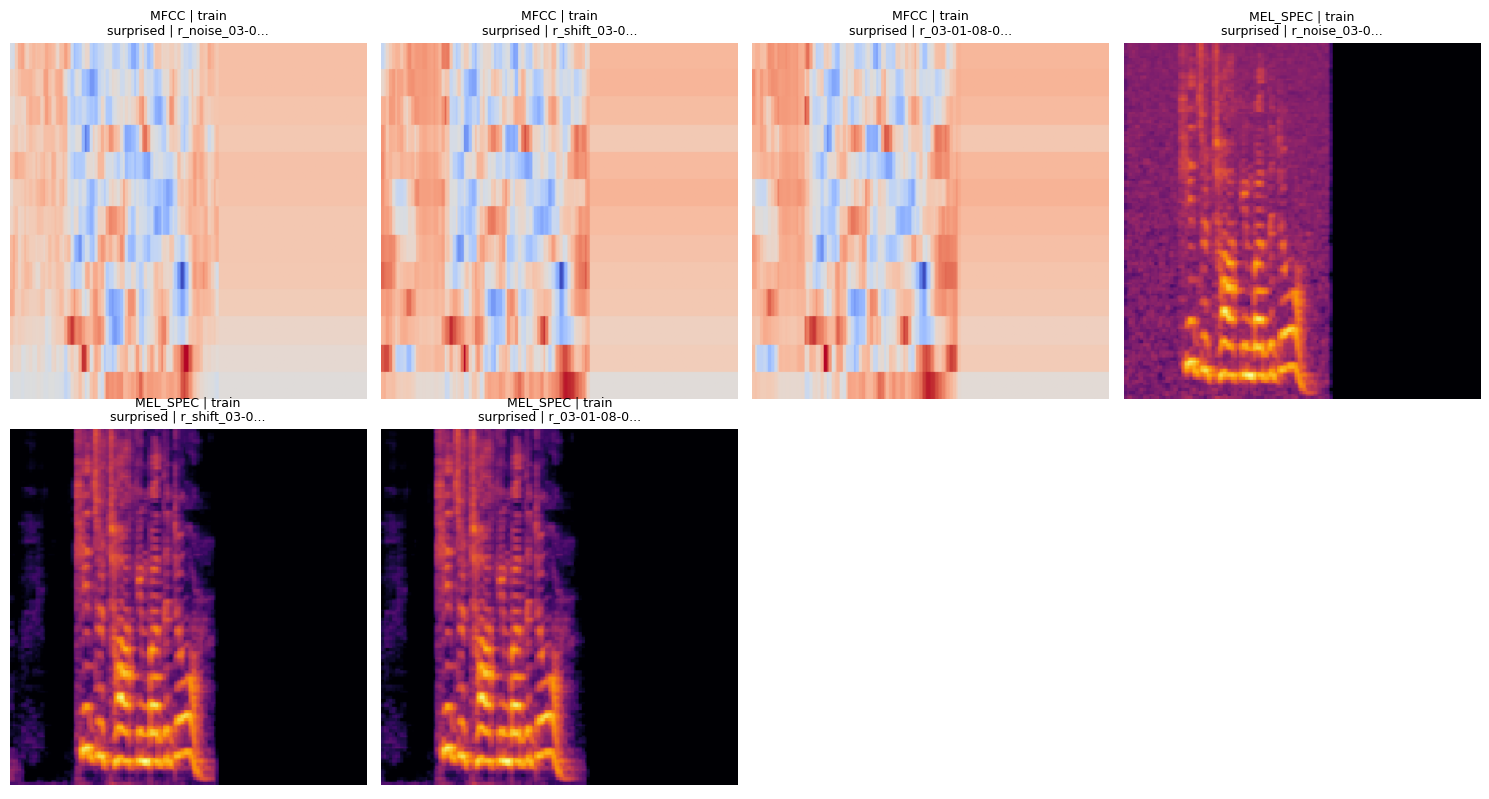

Validación finalizada. Entorno restaurado para producción.


In [33]:
import matplotlib.image as mpimg

# 1. Configuración del entorno temporal
PREVIEW_DIR = '/content/preview_temp'
os.makedirs(PREVIEW_DIR, exist_ok=True)
ORIGINAL_OUT_DIR = OUT_DIR_IMAGES
OUT_DIR_IMAGES = PREVIEW_DIR

# 2. Selección estratégica: 1 RAVDESS (idealmente surprised) y 1 CREMA-D
ravdess_preview = next((f for f in all_files if '03-01-08' in f), next((f for f in all_files if '03-' in f), None))
crema_preview = next((f for f in all_files if 'c_' in get_actor_and_emotion(os.path.basename(f))[0]), None)
preview_files = [f for f in [ravdess_preview, crema_preview] if f is not None]

print("Generando imágenes de prueba...")
for f in preview_files:
    process_single_file_for_images(f)

# 3. Visualización en Colab
generated_pngs = [os.path.join(root, file) for root, _, files in os.walk(PREVIEW_DIR) for file in files if file.endswith('.png')]

if not generated_pngs:
    print("CRÍTICO: No se generó ninguna imagen. Revisa los logs de error.")
else:
    %matplotlib inline
    cols = 4
    rows = (len(generated_pngs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    axes = axes.flatten() if rows * cols > 1 else [axes]

    for idx, png_path in enumerate(generated_pngs):
        img = mpimg.imread(png_path)
        axes[idx].imshow(img)
        axes[idx].axis('off')

        parts = png_path.replace(PREVIEW_DIR + '/', '').split('/')
        if len(parts) >= 3:
            title = f"{parts[0].upper()} | {parts[1]}\n{parts[2]} | {parts[-1][:12]}..."
            axes[idx].set_title(title, fontsize=9)

    for i in range(len(generated_pngs), len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
    matplotlib.use('Agg')

# 4. Restaurar configuración de producción
OUT_DIR_IMAGES = ORIGINAL_OUT_DIR
print("Validación finalizada. Entorno restaurado para producción.")

In [34]:
if GENERATE_IMAGES:
    # Deduplicación por seguridad (bug de Kaggle con RAVDESS)
    unique_files = []
    seen_bases = set()
    for actor, files in actor_to_files.items():
        for f in files:
            base = os.path.basename(f)
            if base not in seen_bases:
                unique_files.append(f)
                seen_bases.add(base)

    print(f"Iniciando extracción masiva para {len(unique_files)} archivos únicos...")

    processed_count = 0
    with ProcessPoolExecutor() as executor:
        futures = {executor.submit(process_single_file_for_images, fp): fp for fp in unique_files}

        for future in tqdm(as_completed(futures), total=len(unique_files), desc="Generando PNGs"):
            if future.result():
                processed_count += 1
            if processed_count % 500 == 0:
                gc.collect()

    print(f"¡Extracción completada!")
    print("-------------------------------------------------")
    print(f"{processed_count} archivos procesados con éxito.")
    print(f"Directorio listo para PyTorch ImageFolder: {OUT_DIR_IMAGES}")
else:
    print("La generación de imágenes está desactivada (GENERATE_IMAGES = False).")

Iniciando extracción masiva para 8882 archivos únicos...


Generando PNGs: 100%|██████████| 8882/8882 [25:53<00:00,  5.72it/s]

¡Extracción completada! 8882 archivos procesados con éxito.
Directorio listo para PyTorch ImageFolder: /content/dataset_split_images


In [35]:
os.listdir(OUT_DIR_IMAGES)

['mfcc', 'mel_spec']

In [56]:
# Guardando el resultado en Drive
generar_copia= False

if generar_copia:

  !zip -r -q /content/dataset_split_img.zip /content/dataset_split_images
  print("archivo comprimido")
  # Mover el archivo zip a Google Drive
  !cp /content/dataset_split_img.zip /content/drive/MyDrive/ravdess_and_crema_images_224_224.zip
  print("Copia de seguridad en Drive completada.")

else:
  print(f"generar_copia: {generar_copia}")


generar_copia: False
